<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv
Dataset shape: (50000, 32)
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestSco

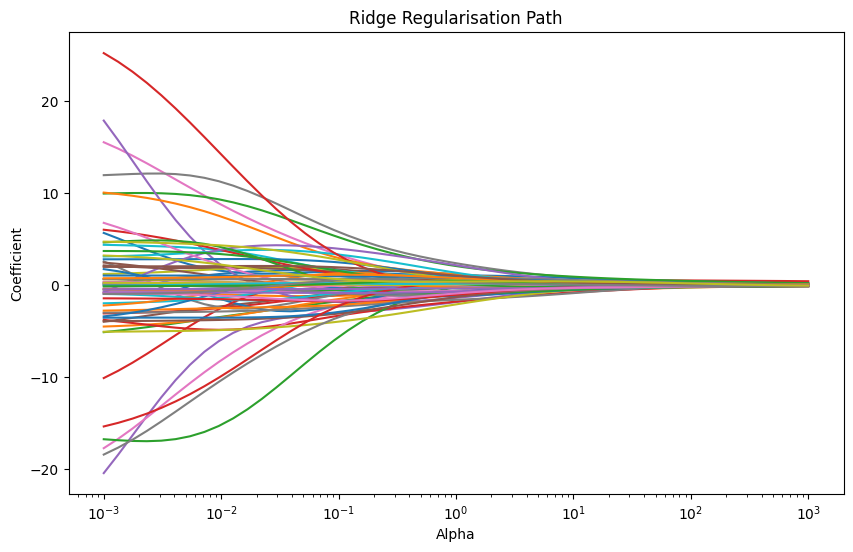

Best Ridge alpha: 0.00954
Best Lasso alpha: 0.00109
Features kept: 16


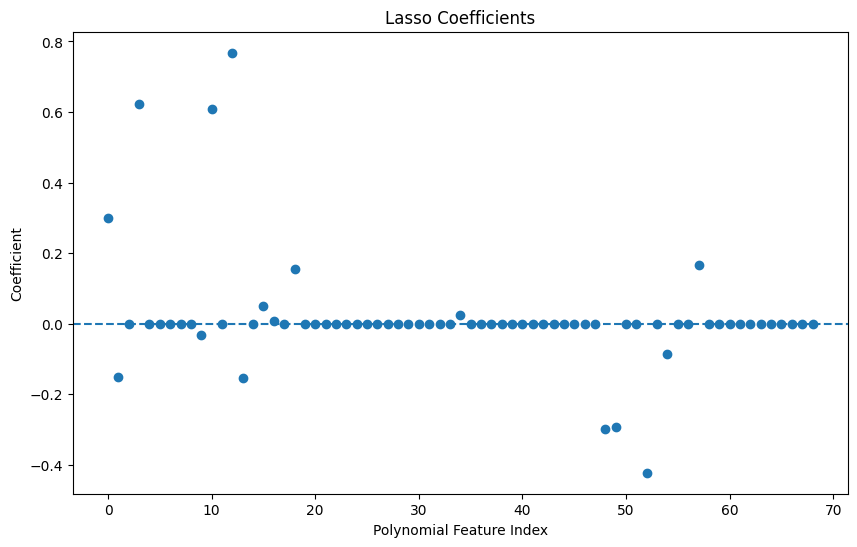

Features selected by Lasso:
                                               Feature  Coefficient
                              Projects CodingTestScore     0.768043
                                       CodingTestScore     0.622327
                           Internships CodingTestScore     0.609069
          AttendancePercent Projects CodingTestScore^2    -0.422241
AttendancePercent Internships Projects CodingTestScore    -0.299053
                                     AttendancePercent     0.298958
       AttendancePercent Internships CodingTestScore^2    -0.291829
                              Internships^2 Projects^2     0.167151
                       AttendancePercent Internships^2     0.155710
                                     CodingTestScore^2    -0.152978
                                           Internships    -0.150586
                                         Internships^4    -0.084785
                       AttendancePercent^2 Internships     0.049193
                    

In [1]:
from google.colab import files

uploaded = files.upload()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
df = pd.read_csv("placement_predict_50k Dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())

# Cell 4 - Select Features

features = [
    "AttendancePercent",
    "Internships",
    "Projects",
    "CodingTestScore"
]

target = "CGPA"

data = df[features + [target]].copy()

# Handle missing values
for col in features + [target]:
    data[col] = data[col].fillna(data[col].median())

X_original = data[features]
y = data[target]

print("Features:", features)
print("Target:", target)
print("\nMissing values:")
print(data.isnull().sum())

# Cell 5 - Polynomial Features

poly = PolynomialFeatures(
    degree=4,
    include_bias=False
)

X = poly.fit_transform(X_original)

print("Original features:", X_original.shape[1])
print("Features after polynomial expansion:", X.shape[1])

# Cell 6 - Train/Test Split

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training data:", Xtr.shape)
print("Testing data :", Xte.shape)

# Cell 7 - Standardization

sc = StandardScaler()

Xtr = sc.fit_transform(Xtr)
Xte = sc.transform(Xte)

print("Standardization completed successfully.")

# Cell 8 - Compare OLS, Ridge, Lasso and Elastic Net

models = [
    ("OLS", LinearRegression()),
    ("Ridge", Ridge(alpha=10)),
    ("Lasso", Lasso(alpha=0.01, max_iter=20000)),
    ("ElasticNet", ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=20000
    ))
]

for name, model in models:

    model.fit(Xtr, ytr)

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    train_rmse = np.sqrt(
        mean_squared_error(ytr, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(yte, test_pred)
    )

    non_zero = np.sum(
        np.abs(model.coef_) > 1e-6
    )

    print(
        f"{name:<12} "
        f"train RMSE={train_rmse:.4f} "
        f"test RMSE={test_rmse:.4f} "
        f"non-zero={non_zero}"
    )

    # Cell 9 - Ridge Regularisation Path

alphas = np.logspace(-3, 3, 50)

coefs = []

for alpha in alphas:

    model = Ridge(alpha=alpha)
    model.fit(Xtr, ytr)

    coefs.append(model.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10, 6))

plt.plot(alphas, coefs)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("Ridge Regularisation Path")

plt.show()

# Cell 10 - RidgeCV

alphas = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(
    alphas=alphas
)

ridge_cv.fit(Xtr, ytr)

print(
    "Best Ridge alpha:",
    round(ridge_cv.alpha_, 5)
)
# Cell 11 - LassoCV

lasso_cv = LassoCV(
    cv=5,
    max_iter=20000,
    random_state=42
)

lasso_cv.fit(Xtr, ytr)

print(
    "Best Lasso alpha:",
    round(lasso_cv.alpha_, 5)
)

print(
    "Features kept:",
    np.sum(
        np.abs(lasso_cv.coef_) > 1e-6
    )
)

# Cell 12 - Lasso Coefficients

plt.figure(figsize=(10, 6))

plt.plot(
    range(len(lasso_cv.coef_)),
    lasso_cv.coef_,
    'o'
)

plt.axhline(0, linestyle='--')

plt.xlabel("Polynomial Feature Index")
plt.ylabel("Coefficient")
plt.title("Lasso Coefficients")

plt.show()

# Cell 13 - Polynomial Feature Names

feature_names = poly.get_feature_names_out(features)

lasso_selected = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_cv.coef_
})

lasso_selected = lasso_selected[
    np.abs(lasso_selected["Coefficient"]) > 1e-6
]

lasso_selected = lasso_selected.sort_values(
    "Coefficient",
    key=np.abs,
    ascending=False
)

print("Features selected by Lasso:")
print(lasso_selected.to_string(index=False))

# Cell 14 - Final Comparison

results = []

for name, model in models:

    model.fit(Xtr, ytr)

    train_pred = model.predict(Xtr)
    test_pred = model.predict(Xte)

    train_rmse = np.sqrt(
        mean_squared_error(ytr, train_pred)
    )

    test_rmse = np.sqrt(
        mean_squared_error(yte, test_pred)
    )

    results.append({
        "Model": name,
        "Train RMSE": round(train_rmse, 4),
        "Test RMSE": round(test_rmse, 4)
    })

results_df = pd.DataFrame(results)

print("========== MODEL COMPARISON ==========")
print(results_df.to_string(index=False))

print("\nBest Ridge alpha:", round(ridge_cv.alpha_, 5))
print("Best Lasso alpha:", round(lasso_cv.alpha_, 5))
print(
    "Lasso features kept:",
    np.sum(np.abs(lasso_cv.coef_) > 1e-6)
)

# Cell 15 - Conclusion

best_model = results_df.loc[
    results_df["Test RMSE"].idxmin(),
    "Model"
]

print("========== EXPERIMENT 5 CONCLUSION ==========")

print(
    "The models were compared using test RMSE."
)

print(
    "Best performing model:",
    best_model
)

print(
    "Ridge uses L2 regularisation to shrink coefficients."
)

print(
    "Lasso uses L1 regularisation and can remove features "
    "by making their coefficients zero."
)

print(
    "Elastic Net combines L1 and L2 regularisation."
)